# Holiday Destination Index — Combined Analysis
---

This notebook combines three cleaned datasets into a single master CSV and then performs a full multivariate analysis to build a composite *'Best Country to Visit'* index.

**Datasets used:**

| Dataset | Source File | Pillar |
|---|---|---|
| Cost of Living | `Cleaned_CostOfLiving.csv` | Economy |
| Global Weather | `Cleaned_GlobalWeather.csv` | Environment |
| Natural Disasters | `Cleaned_NaturalDisasters.csv` | Risk |

---

## Part 1 — Data Loading & Combination

Load the three cleaned CSV files, verify each for NaN values, merge them on `country`, and export the final combined dataset.

### 1.1 — Load Datasets


In [10]:
import pandas as pd

# Load the three cleaned datasets 
cost_of_living = pd.read_csv('Cleaned_Csvs/Cleaned_CostOfLiving.csv')
weather        = pd.read_csv('Cleaned_Csvs/Cleaned_GlobalWeather.csv')
disasters      = pd.read_csv('Cleaned_Csvs/Cleaned_NaturalDisasters.csv')

print(f"Cost of Living rows : {len(cost_of_living)}")
print(f"Weather rows        : {len(weather)}")
print(f"Disasters rows      : {len(disasters)}")

for name, df in [("Cost of Living", cost_of_living), ("Weather", weather), ("Disasters", disasters)]:
    nan_counts = df.isnull().sum()
    nan_counts = nan_counts[nan_counts > 0]
    print(f"\n--- {name} NaN counts ---")
    if nan_counts.empty:
        print("  No NaN values")
    else:
        print(nan_counts.to_string())


Cost of Living rows : 203
Weather rows        : 201
Disasters rows      : 156

--- Cost of Living NaN counts ---
  No NaN values

--- Weather NaN counts ---
  No NaN values

--- Disasters NaN counts ---
  No NaN values


### 1.2 — Merge Datasets

Merge the three datasets on `country`:
- **Inner join** `CostOfLiving` + `Weather` — only countries present in both are kept.
- **Left join** `Disasters` onto the result — countries with no disaster record are filled with `0`, assuming no recorded events.


In [11]:
# Step 1: inner join cost_of_living + weather (both MUST be present)
combined = pd.merge(
    cost_of_living, 
    weather, 
    on='country', 
    how='inner'
)
print(f"After inner join (cost_of_living + weather): {len(combined)} rows")

# Step 2: left join disasters onto combined
disaster_numeric_cols = disasters.select_dtypes(include='number').columns.tolist()

combined = pd.merge(
    combined,
    disasters,
    on='country',
    how='left'
)

# Fill missing disaster numeric values with 0
# For countries in 'combined' that don't appear in the disaster dataset I assume they had 0 disasters
# so I fill NaNs with 0
combined[disaster_numeric_cols] = combined[disaster_numeric_cols].fillna(0)

# Sort by country and reset index
combined = combined.sort_values('country').reset_index(drop=True)

print(f"Combined rows : {len(combined)}")
print(f"Combined cols : {combined.shape[1]}")
combined.head(10)

After inner join (cost_of_living + weather): 170 rows
Combined rows : 170
Combined cols : 14


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment,temperature_celsius,condition_text,wind_kph,humidity,uv_index,condition_category,HRS_of_light,Disaster_Count,Median_Severity,Unique_Days_Under_Threat
0,Afghanistan,3.41,0.22,79.900,26.6,partly cloudy,13.3,24,7.0,Partly Cloudy,0.58,6.0,0.50,22.0
1,Albania,12.48,0.43,186.790,19.0,partly cloudy,11.2,94,5.0,Partly Cloudy,0.61,1.0,0.00,7.0
2,Algeria,6.66,0.21,143.880,23.0,sunny,15.1,29,5.0,Clear,0.59,5.0,0.25,8.0
3,Andorra,20.17,1.90,811.730,6.3,light drizzle,11.9,61,2.0,Rain,0.61,0.0,0.00,0.0
4,Angola,32.12,0.59,220.390,26.0,partly cloudy,13.0,89,8.0,Partly Cloudy,0.49,2.0,1.00,11.0
5,Antigua And Barbuda,46.26,1.02,393.905,26.0,partly cloudy,9.0,84,1.0,Partly Cloudy,0.54,0.0,0.00,0.0
6,Argentina,13.76,0.35,205.320,8.0,clear,3.6,93,1.0,Clear,0.43,4.0,0.50,62.0
7,Armenia,15.84,0.25,540.260,19.0,partly cloudy,6.8,40,4.0,Partly Cloudy,0.60,2.0,0.50,6.0
8,Australia,31.15,2.75,1142.780,9.0,clear,4.0,87,1.0,Clear,0.43,8.0,0.25,27.0
9,Austria,28.49,2.41,707.550,16.0,partly cloudy,20.2,63,5.0,Partly Cloudy,0.64,2.0,0.00,9.0


### 1.3 — Export Combined Dataset

Save the merged 170-row dataset to `Combined_Holiday.csv` for use in all subsequent analysis.


In [12]:
combined.to_csv('Combined_Holiday.csv', index=False)
print("Saved to Combined_Holiday.csv")
combined.info()

Saved to Combined_Holiday.csv
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         170 non-null    str    
 1   Mid_range_meal_pp               170 non-null    float64
 2   One_way_local_transport_ticket  170 non-null    float64
 3   Apartment                       170 non-null    float64
 4   temperature_celsius             170 non-null    float64
 5   condition_text                  170 non-null    str    
 6   wind_kph                        170 non-null    float64
 7   humidity                        170 non-null    int64  
 8   uv_index                        170 non-null    float64
 9   condition_category              170 non-null    str    
 10  HRS_of_light                    170 non-null    float64
 11  Disaster_Count                  170 non-null    float64
 12  Median_Severity  

# Part 2 — Multivariate Analysis: PCA for a Global Stability & Cost Index
---
Principal Component Analysis (PCA) is used to uncover the underlying structure of the dataset across all **three datasets**:

| Dataset | Indicators |
|---|---|
| **Economy** | `Mid_range_meal_pp`, `One_way_local_transport_ticket`, `Apartment` |
| **Environment** | `temperature_celsius`, `wind_kph`, `humidity`, `uv_index`, `HRS_of_light` |
| **Risk** | `Disaster_Count`, `Median_Severity`, `Unique_Days_Under_Threat` |

PCA reduces these 11 dimensions to orthogonal components, revealing which indicators drive variance across countries and how countries cluster in reduced space.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates

df = pd.read_csv('Combined_Holiday.csv')

NUMERIC_COLS = [
    'Mid_range_meal_pp', 'One_way_local_transport_ticket', 'Apartment',
    'temperature_celsius', 'wind_kph', 'humidity', 'uv_index', 'HRS_of_light',
    'Disaster_Count', 'Median_Severity', 'Unique_Days_Under_Threat'
]


## 2.1 — Correlation Heatmap
Shows the pairwise correlation between all numeric features. Strong positive/negative correlations indicate variables that have high correlation.

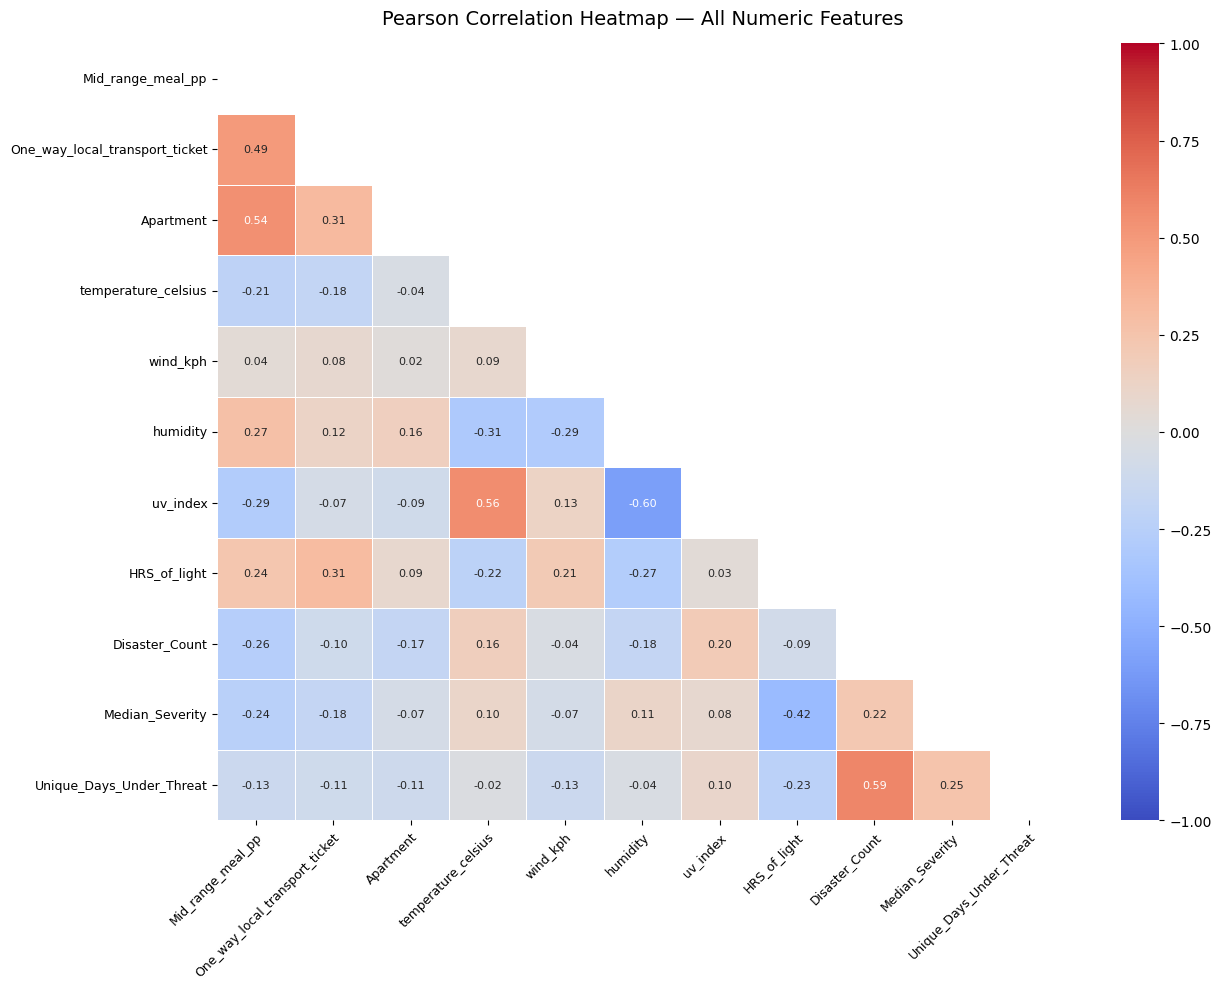

In [14]:
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle masked
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title('Pearson Correlation Heatmap — All Numeric Features', fontsize=14, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


### Findings

To interpret the heatmap, I used the following standard thresholds:

| Range (absolute value) | Strength |
|---|---|
| 0.8 – 1.0 | Perfect / Very Strong |
| 0.6 – 0.8 | Strong |
| 0.4 – 0.6 | Moderate |
| 0.2 – 0.4 | Weak |
| 0.0 – 0.2 | Negligible / No correlation |

By analysing the relationships between my variables using the heatmap, I found that **most correlations fall in the weak-to-no-correlation range**, with the exception of a few notable outliers outlined below.

---

**Humidity vs. UV Index (`-0.60`) — Strong Negative**
High humidity typically means more cloud cover, which blocks UV light. This makes intuitive sense: if you want a dry, sunny holiday destination, you'll likely encounter higher UV levels.

**Disaster Count vs. Days Under Threat (`+0.59`) — Moderate–Strong Positive**
These two metrics move together logically — the more individual disaster events a country experiences, the more days it will naturally be flagged as under threat.

**Temperature vs. UV Index (`+0.56`) — Moderate Positive**
As expected, hotter countries tend to experience more intense direct sunlight, resulting in higher UV readings.

**The "Cost Cluster" — Moderate Positive**
`Mid_range_meal_pp` correlates with both `Apartment` (`0.54`) and `One_way_local_transport_ticket` (`0.49`). This confirms that prices across different sectors tend to rise and fall together within a country, reinforcing the validity of grouping them into a single **Economic Pillar** for the index.

**The Unusual Find — Severity vs. Hours of Light (`-0.42`) — Moderate Negative**
Countries with more daylight hours tended to record lower disaster severity in this dataset. This likely reflects the geographic reality that higher-latitude summer destinations (which have long daylight hours) are less exposed to the severe natural disasters that affect tropical regions. It's a good reminder that **geography plays a significant role** in travel safety.


## 2.3 — Scree Plot 

The scree plot shows how many components are needed to capture the majority of the dataset's variance. The **elbow** (where the individual bars flatten) marks the natural cut-off. The orange line shows cumulative variance.


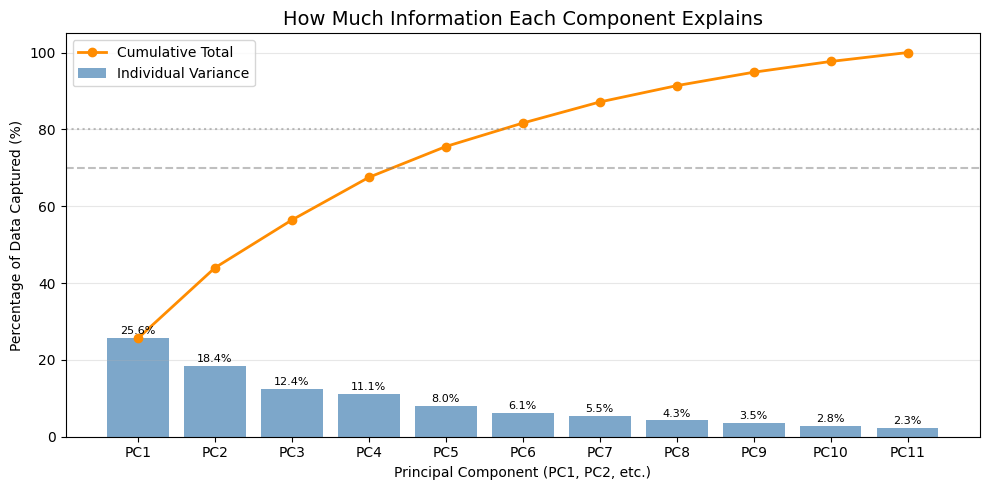

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardise (scales differ: €, °C, disaster counts)
X_std = StandardScaler().fit_transform(df[NUMERIC_COLS].fillna(0).values)

# Fit PCA on all components
pca      = PCA(random_state=42)
pca.fit(X_std)
n_comp   = len(NUMERIC_COLS)
ev_ratio = pca.explained_variance_ratio_ * 100
ev_cum   = np.cumsum(ev_ratio)

# Loadings table
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=NUMERIC_COLS
)


# ── Scree plot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
components = np.arange(1, n_comp + 1)

plt.bar(components, ev_ratio, color='steelblue', alpha=0.7, label='Individual Variance')
plt.plot(components, ev_cum, color='darkorange', marker='o', linewidth=2, label='Cumulative Total')

plt.axhline(y=70, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=80, color='gray', linestyle=':', alpha=0.5)

for i, percentage in enumerate(ev_ratio):
    plt.text(i + 1, percentage + 1, f'{percentage:.1f}%', ha='center', fontsize=8)

plt.title('How Much Information Each Component Explains', fontsize=14)
plt.xlabel('Principal Component (PC1, PC2, etc.)')
plt.ylabel('Percentage of Data Captured (%)')
plt.xticks(components, [f'PC{i}' for i in components])
plt.legend(loc='best')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Scree Plot Interpretation

To develop a meaningful composite indicator, I performed **Principal Component Analysis (PCA)** on the 11 numeric variables in the dataset. This allowed me to study the underlying structure of the data and ensure that the final index represents a truly multidimensional concept, rather than being driven by a single factor.

The scree plot above reveals a distinct **'elbow' at the sixth component**, which is where the addition of further components begins to yield diminishing returns in terms of explained variance.

- **Variance Captured:** By retaining **6 Principal Components**, I capture **81.6%** of the total variation across countries — a threshold I consider sufficient for building my index.
- **Dimensionality:** Keeping these six components ensures that the final *'Best Country to Visit'* index reflects the multidimensional nature of travel, rather than collapsing everything into a single metric and having one factor — such as cost — dominate the result.
